# alpha_signal — Alpha Threshold Analysis

Computes the daily forward return signal **(close_{t+1} − vwap_t) / vwap_t** for every
asset-day and helps choose a good ALPHA cutoff for the three-class label used in
feishuv2 / feishuv3.

**Sections**
1. Setup
2. Load data & compute signal
3. Return distribution overview
4. Alpha threshold scan
5. Per-asset analysis
6. Temporal analysis
7. Recommendation

---
## 1. Setup

In [20]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings("ignore")

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = "../data"
OHLCV_PARQUET = os.path.join(DATA_DIR, "daily_data_in_sample.parquet")
VWAP_COL = "vwap_0930_0935"  # day-t entry price

# ── alpha candidates to scan ──────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.001, 0.016, 0.001), 4)  # 0.1 % … 1.5 %
CURRENT_ALPHA = 0.002  # value used in feishuv2 / feishuv3

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("ALPHAS:", ALPHAS)

ALPHAS: [0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011 0.012
 0.013 0.014 0.015]


---
## 2. Load Data & Compute Signal

In [21]:
ohlcv = pd.read_parquet(OHLCV_PARQUET)

# normalise date column name
if "trade_day_id" in ohlcv.columns and "date" not in ohlcv.columns:
    ohlcv = ohlcv.rename(columns={"trade_day_id": "date"})

print(
    f"OHLCV : {len(ohlcv):,} rows  "
    f"assets={ohlcv['asset_id'].nunique()}  "
    f"dates={ohlcv['date'].nunique()}"
)
print(f"VWAP  : {VWAP_COL}")
print(f"Range : {ohlcv['date'].min()} → {ohlcv['date'].max()}")
print("Columns:", list(ohlcv.columns))

OHLCV : 1,060,121 rows  assets=2270  dates=484
VWAP  : vwap_0930_0935
Range : D001 → D484
Columns: ['asset_id', 'date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'adj_factor', 'vwap_0930_0935']


In [22]:
# per-asset forward return: (close_{t+1} − vwap_t) / |vwap_t|
ohlcv = ohlcv.sort_values(["asset_id", "date"]).reset_index(drop=True)
ohlcv["next_close"] = ohlcv.groupby("asset_id")["close"].shift(-1)
ohlcv["ret"] = (ohlcv["next_close"] - ohlcv[VWAP_COL]) / (ohlcv[VWAP_COL].abs() + 1e-9)

# drop last row per asset (no next_close) and degenerate VWAP rows
rets = ohlcv.dropna(subset=["ret", "next_close"]).copy()
rets = rets[rets[VWAP_COL].abs() > 0.01]
r = rets["ret"].values

print(f"Valid observations : {len(r):,}")
print(f"  Assets           : {rets['asset_id'].nunique()}")
print(f"  Trading days     : {rets['date'].nunique()}")
print(f"  Obs / asset avg  : {len(r) / rets['asset_id'].nunique():.0f}")

Valid observations : 1,057,817
  Assets           : 2270
  Trading days     : 483
  Obs / asset avg  : 466


---
## 3. Return Distribution Overview

In [23]:
# summary statistics
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(r, pcts)

print("── Summary statistics ───────────────────────────────────────────────────")
print(f"  N      : {len(r):,}")
print(f"  Mean   : {r.mean():+.5f}")
print(f"  Std    : {r.std():.5f}")
print(f"  Skew   : {stats.skew(r):.3f}")
print(f"  Kurt   : {stats.kurtosis(r):.3f}  (excess)")
print()
print("Percentiles:")
for p, v in zip(pcts, pct_vals):
    print(f"  {p:3d}th : {v:+.5f}")

── Summary statistics ───────────────────────────────────────────────────
  N      : 1,057,817
  Mean   : -0.00008
  Std    : 0.03712
  Skew   : 0.481
  Kurt   : 10.777  (excess)

Percentiles:
    1th : -0.09370
    5th : -0.05275
   10th : -0.03751
   25th : -0.01848
   50th : -0.00177
   75th : +0.01587
   90th : +0.03894
   95th : +0.05891
   99th : +0.11563


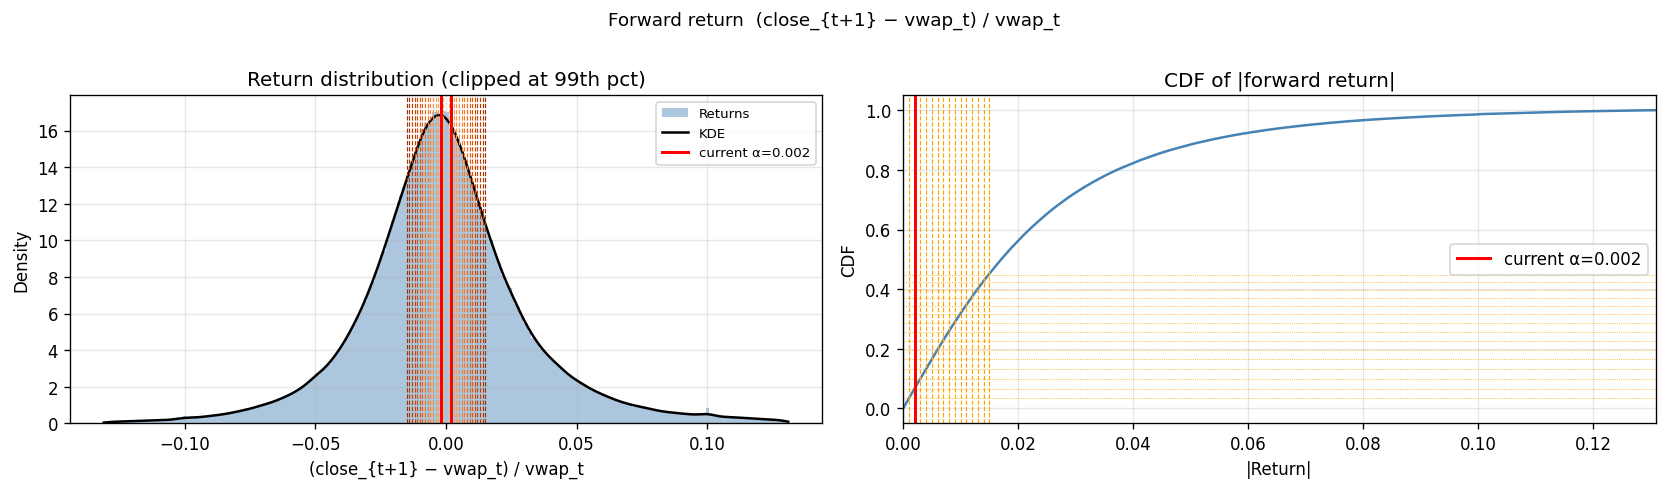

In [24]:
clip_pct = 99  # clip display at 99th percentile of |r| for readability
clip_val = np.percentile(np.abs(r), clip_pct)
r_disp = r[np.abs(r) <= clip_val]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── left: histogram + KDE ─────────────────────────────────────────────────────
ax = axes[0]
ax.hist(r_disp, bins=250, density=True, color="steelblue", alpha=0.45, label="Returns")
kde_x = np.linspace(r_disp.min(), r_disp.max(), 600)
kde = stats.gaussian_kde(r_disp, bw_method=0.08)
ax.plot(kde_x, kde(kde_x), "k-", lw=1.5, label="KDE")

cmap = plt.cm.Oranges(np.linspace(0.35, 0.9, len(ALPHAS)))
for a, col in zip(ALPHAS, cmap):
    ax.axvline(a, color=col, lw=0.7, linestyle="--")
    ax.axvline(-a, color=col, lw=0.7, linestyle="--")
ax.axvline(CURRENT_ALPHA, color="red", lw=1.8, label=f"current α={CURRENT_ALPHA}")
ax.axvline(-CURRENT_ALPHA, color="red", lw=1.8)

ax.set_xlabel("(close_{t+1} − vwap_t) / vwap_t")
ax.set_ylabel("Density")
ax.set_title(f"Return distribution (clipped at {clip_pct}th pct)")
ax.legend(fontsize=8)

# ── right: CDF of |return| ────────────────────────────────────────────────────
ax2 = axes[1]
abs_sorted = np.sort(np.abs(r_disp))
cdf = np.arange(1, len(abs_sorted) + 1) / len(abs_sorted)
ax2.plot(abs_sorted, cdf, "steelblue", lw=1.5)
for a in ALPHAS:
    frac_signal = (np.abs(r) > a).mean()
    ax2.axvline(a, color="orange", lw=0.7, linestyle="--")
    ax2.axhline(1 - frac_signal, color="orange", lw=0.5, linestyle=":")
ax2.axvline(CURRENT_ALPHA, color="red", lw=1.8, label=f"current α={CURRENT_ALPHA}")
ax2.set_xlabel("|Return|")
ax2.set_ylabel("CDF")
ax2.set_title("CDF of |forward return|")
ax2.set_xlim(0, clip_val)
ax2.legend()

plt.suptitle("Forward return  (close_{t+1} − vwap_t) / vwap_t", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

---
## 4. Alpha Threshold Scan

For each candidate α compute the fraction of samples labelled **down** (ret < −α), **flat** (|ret| ≤ α), **up** (ret > α) and the down/up imbalance ratio.

In [25]:
rows = []
for a in ALPHAS:
    n_down = int((r < -a).sum())
    n_up = int((r > a).sum())
    n_flat = int(((r >= -a) & (r <= a)).sum())
    total = len(r)
    rows.append(
        {
            "alpha": a,
            "n_down": n_down,
            "n_flat": n_flat,
            "n_up": n_up,
            "pct_down": 100 * n_down / total,
            "pct_flat": 100 * n_flat / total,
            "pct_up": 100 * n_up / total,
            "imbalance": max(n_down, n_up) / (min(n_down, n_up) + 1),
        }
    )

scan = pd.DataFrame(rows).set_index("alpha")
print(
    scan.to_string(
        float_format=lambda x: f"{x:.2f}",
        formatters={
            "n_down": "{:,.0f}".format,
            "n_flat": "{:,.0f}".format,
            "n_up": "{:,.0f}".format,
        },
    )
)

       n_down  n_flat    n_up  pct_down  pct_flat  pct_up  imbalance
alpha                                                               
0.001 542,694  35,779 479,344     51.30      3.38   45.31       1.13
0.002 524,943  70,497 462,377     49.63      6.66   43.71       1.14
0.003 507,210 105,132 445,475     47.95      9.94   42.11       1.14
0.004 489,375 139,795 428,647     46.26     13.22   40.52       1.14
0.005 471,606 173,951 412,260     44.58     16.44   38.97       1.14
0.006 454,052 207,419 396,346     42.92     19.61   37.47       1.15
0.007 436,785 240,153 380,879     41.29     22.70   36.01       1.15
0.008 419,582 272,550 365,685     39.66     25.77   34.57       1.15
0.009 402,503 304,223 351,091     38.05     28.76   33.19       1.15
0.010 386,149 334,573 337,095     36.50     31.63   31.87       1.15
0.011 370,233 364,077 323,507     35.00     34.42   30.58       1.14
0.012 354,482 392,944 310,391     33.51     37.15   29.34       1.14
0.013 339,169 420,754 297,894     

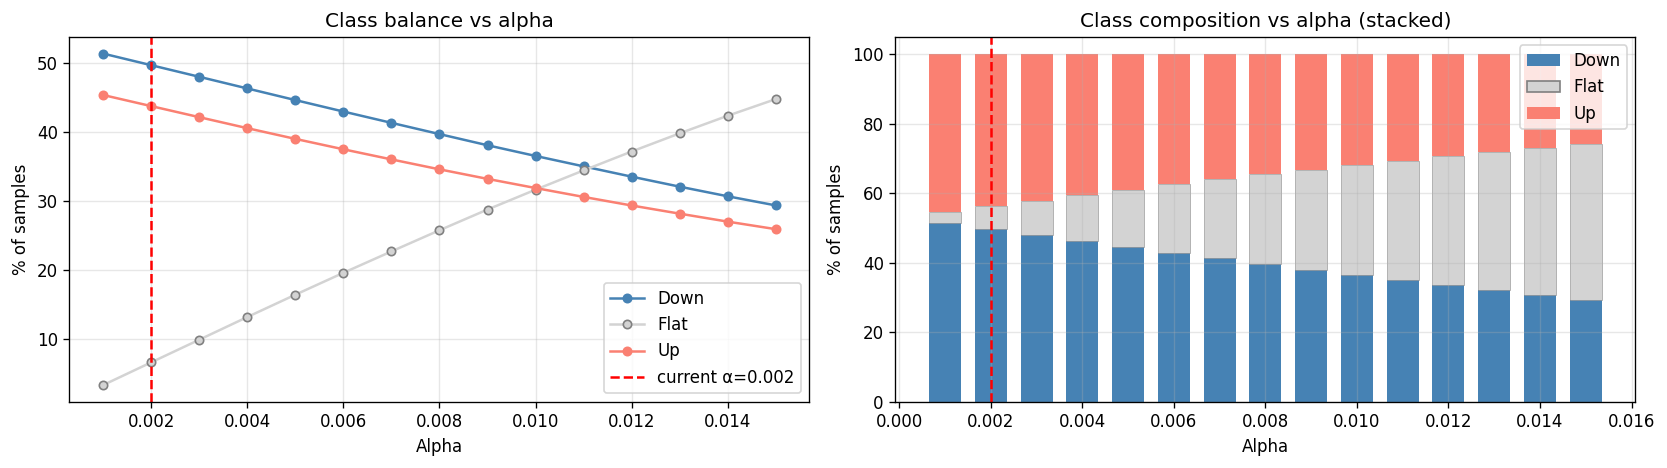

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── left: fraction per class vs alpha ─────────────────────────────────────────
ax = axes[0]
ax.plot(scan.index, scan["pct_down"], "o-", color="steelblue", ms=5, label="Down")
ax.plot(
    scan.index,
    scan["pct_flat"],
    "o-",
    color="lightgray",
    ms=5,
    label="Flat",
    markeredgecolor="gray",
)
ax.plot(scan.index, scan["pct_up"], "o-", color="salmon", ms=5, label="Up")
ax.axvline(CURRENT_ALPHA, color="red", lw=1.5, linestyle="--", label=f"current α={CURRENT_ALPHA}")
ax.set_xlabel("Alpha")
ax.set_ylabel("% of samples")
ax.set_title("Class balance vs alpha")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.legend()

# ── right: stacked bar ────────────────────────────────────────────────────────
ax2 = axes[1]
bw = (ALPHAS[1] - ALPHAS[0]) * 0.7
for a in ALPHAS:
    row = scan.loc[a]
    ax2.bar(a, row["pct_down"], width=bw, color="steelblue")
    ax2.bar(
        a,
        row["pct_flat"],
        width=bw,
        bottom=row["pct_down"],
        color="lightgray",
        edgecolor="gray",
        lw=0.3,
    )
    ax2.bar(a, row["pct_up"], width=bw, bottom=row["pct_down"] + row["pct_flat"], color="salmon")
ax2.axvline(CURRENT_ALPHA, color="red", lw=1.5, linestyle="--", label=f"current α={CURRENT_ALPHA}")
from matplotlib.patches import Patch

ax2.legend(
    handles=[
        Patch(facecolor="steelblue", label="Down"),
        Patch(facecolor="lightgray", edgecolor="gray", label="Flat"),
        Patch(facecolor="salmon", label="Up"),
    ],
    loc="upper right",
)
ax2.set_xlabel("Alpha")
ax2.set_ylabel("% of samples")
ax2.set_title("Class composition vs alpha (stacked)")
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.show()

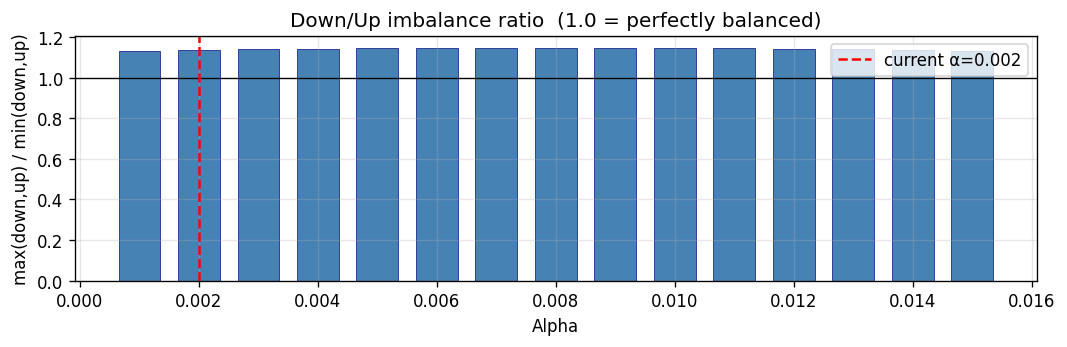

In [27]:
# imbalance (down vs up symmetry) across alphas
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(
    scan.index,
    scan["imbalance"],
    width=(ALPHAS[1] - ALPHAS[0]) * 0.7,
    color="steelblue",
    edgecolor="navy",
    lw=0.4,
)
ax.axhline(1.0, color="black", lw=0.8)
ax.axvline(CURRENT_ALPHA, color="red", lw=1.5, linestyle="--", label=f"current α={CURRENT_ALPHA}")
ax.set_xlabel("Alpha")
ax.set_ylabel("max(down,up) / min(down,up)")
ax.set_title("Down/Up imbalance ratio  (1.0 = perfectly balanced)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Select best alpha based on criteria:
# 1) Minimize imbalance (closest to 1.0)
# 2) Prefer ~30-40% flat class for good signal separation
# 3) Balanced down/up classes

scan["imbalance_score"] = (scan["imbalance"] - 1.0).abs()
scan["flat_target_score"] = (scan["pct_flat"] - 35.0).abs()  # target 35% flat
scan["combined_score"] = scan["imbalance_score"] * 2 + scan["flat_target_score"]

best_alpha = scan["combined_score"].idxmin()

print(f"Best alpha: {best_alpha}")
print(f"  Down: {scan.loc[best_alpha, 'pct_down']:.2f}%")
print(f"  Flat: {scan.loc[best_alpha, 'pct_flat']:.2f}%")
print(f"  Up:   {scan.loc[best_alpha, 'pct_up']:.2f}%")
print(f"  Imbalance: {scan.loc[best_alpha, 'imbalance']:.3f}")
print(f"\nCurrent alpha: {CURRENT_ALPHA}")
print(f"  Down: {scan.loc[CURRENT_ALPHA, 'pct_down']:.2f}%")
print(f"  Flat: {scan.loc[CURRENT_ALPHA, 'pct_flat']:.2f}%")
print(f"  Up:   {scan.loc[CURRENT_ALPHA, 'pct_up']:.2f}%")
print(f"  Imbalance: {scan.loc[CURRENT_ALPHA, 'imbalance']:.3f}")

---
## 5. Per-Asset Analysis

Check whether certain assets drive the distribution or have systematically higher/lower returns.

In [28]:
asset_stats = (
    rets.groupby("asset_id")["ret"]
    .agg(
        mean="mean",
        std="std",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="count",
    )
    .sort_values("median")
)
print(f"Assets: {len(asset_stats)}")
print(asset_stats.head(10).to_string(float_format=lambda x: f"{x:.5f}"))
print("...")
print(asset_stats.tail(10).to_string(float_format=lambda x: f"{x:.5f}"))

Assets: 2270
             mean     std   median      q25      q75    n
asset_id                                                 
A000176  -0.18345 0.09419 -0.18345 -0.21675 -0.15015    2
A000637  -0.00673 0.05453 -0.01717 -0.04015  0.01807  335
A000481  -0.02017 0.06360 -0.01577 -0.05108  0.03501   12
A000841  -0.00568 0.05445 -0.01209 -0.03566  0.01791  483
A001103  -0.00564 0.04977 -0.01181 -0.03061  0.01689  483
A001496  -0.00359 0.06722 -0.01130 -0.03544  0.02577  223
A000970  -0.00446 0.04727 -0.01128 -0.03087  0.01742  483
A001856  -0.01088 0.08204 -0.01118 -0.05002  0.04881  214
A001637  -0.00720 0.04771 -0.01115 -0.03501  0.01753  483
A001984  -0.00609 0.06736 -0.01082 -0.04110  0.01976  115
...
             mean     std  median      q25     q75    n
asset_id                                               
A001812   0.00141 0.03811 0.00333 -0.01477 0.01862  483
A000622   0.00348 0.04539 0.00336 -0.02132 0.02339  483
A000166   0.00550 0.04051 0.00337 -0.01701 0.02476  474
A002090

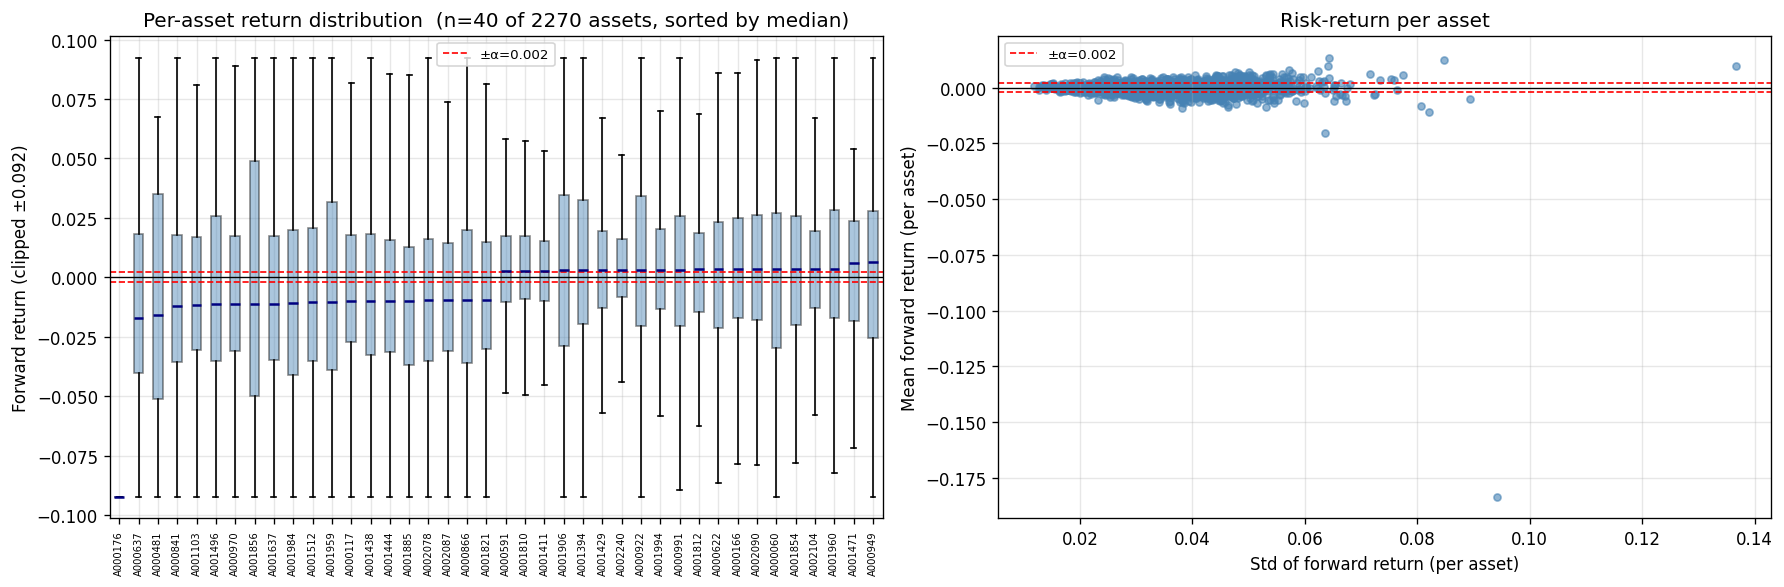

In [29]:
n_assets = len(asset_stats)
# select up to 40 assets: 20 lowest + 20 highest median return
if n_assets > 40:
    selected = asset_stats.index[:20].tolist() + asset_stats.index[-20:].tolist()
else:
    selected = asset_stats.index.tolist()

clip_box = float(np.percentile(np.abs(r), 97))
data_per_asset = [
    rets[rets["asset_id"] == aid]["ret"].clip(-clip_box, clip_box).values for aid in selected
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── left: box plot per asset ──────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(
    data_per_asset,
    vert=True,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="steelblue", alpha=0.45),
    medianprops=dict(color="navy", lw=1.5),
)
ax.axhline(0, color="black", lw=0.8)
ax.axhline(CURRENT_ALPHA, color="red", lw=1.0, linestyle="--", label=f"±α={CURRENT_ALPHA}")
ax.axhline(-CURRENT_ALPHA, color="red", lw=1.0, linestyle="--")
ax.set_xticks(range(1, len(selected) + 1))
ax.set_xticklabels([str(a) for a in selected], rotation=90, fontsize=6)
ax.set_ylabel(f"Forward return (clipped ±{clip_box:.3f})")
ax.set_title(
    f"Per-asset return distribution  (n={len(selected)} of {n_assets} assets, sorted by median)"
)
ax.legend(fontsize=8)

# ── right: risk-return scatter ────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(asset_stats["std"], asset_stats["mean"], s=18, alpha=0.6, color="steelblue")
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(CURRENT_ALPHA, color="red", lw=1.0, linestyle="--", label=f"±α={CURRENT_ALPHA}")
ax2.axhline(-CURRENT_ALPHA, color="red", lw=1.0, linestyle="--")
ax2.set_xlabel("Std of forward return (per asset)")
ax2.set_ylabel("Mean forward return (per asset)")
ax2.set_title("Risk-return per asset")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. Temporal Analysis

Check for structural breaks and regime changes in return magnitude over time — a stable distribution justifies a single fixed ALPHA.

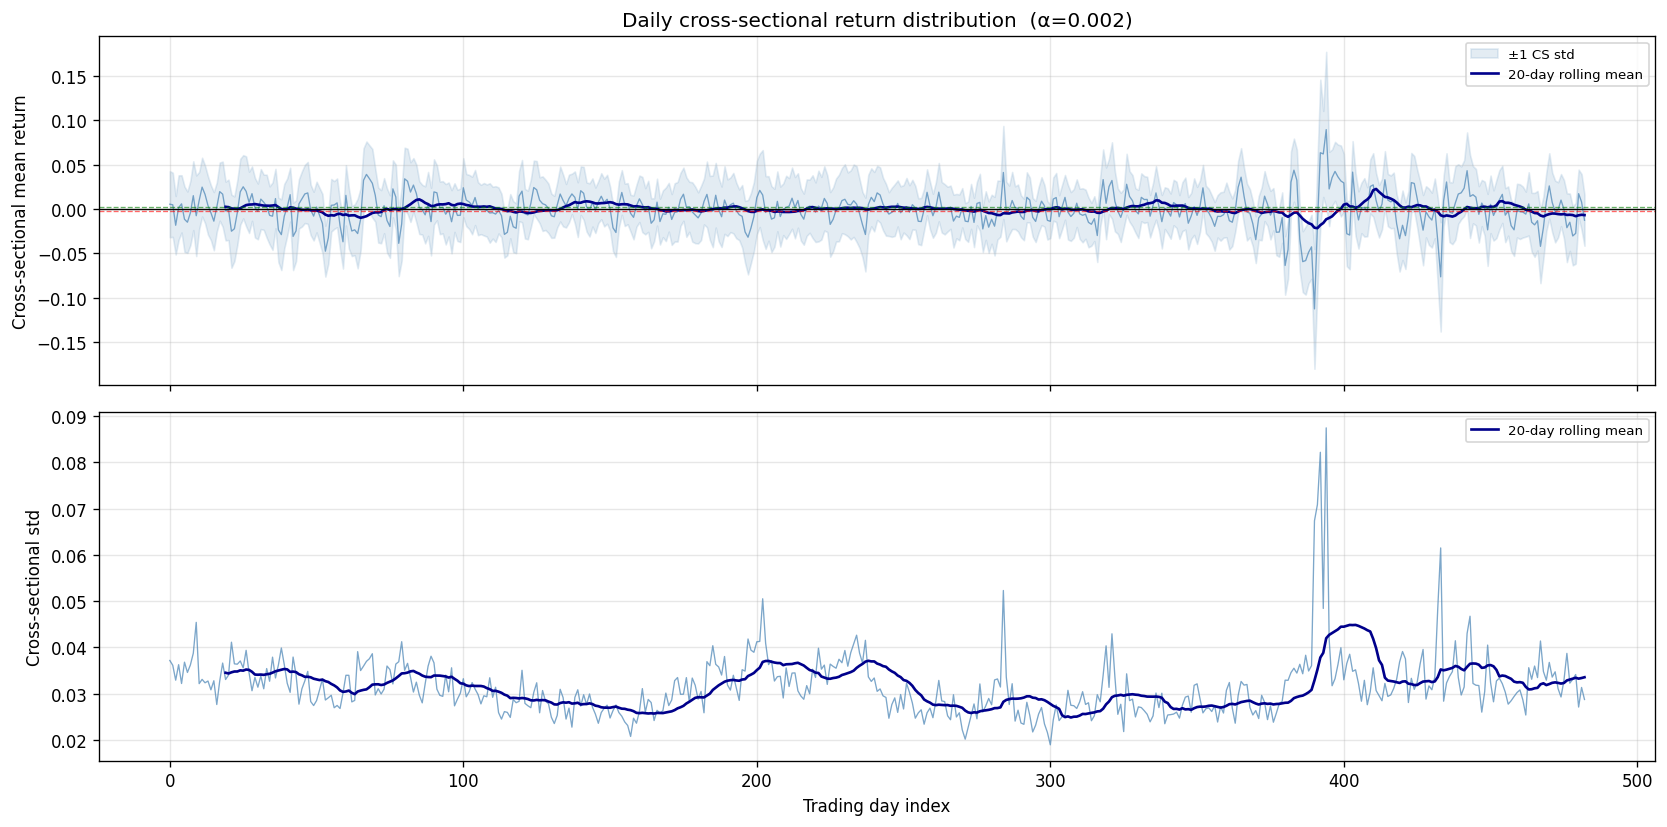

In [30]:
daily = rets.groupby("date")["ret"].agg(mean="mean", std="std", count="count")
# date column is categorical (D001, D002, ...), not datetime — use numeric x-axis
daily = daily.reset_index()
daily["x"] = range(len(daily))

roll20 = daily["mean"].rolling(20)
roll20_std = daily["std"].rolling(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── top: cross-sectional mean return ─────────────────────────────────────────
ax = axes[0]
ax.fill_between(
    daily["x"],
    daily["mean"] - daily["std"],
    daily["mean"] + daily["std"],
    alpha=0.15,
    color="steelblue",
    label="±1 CS std",
)
ax.plot(daily["x"], daily["mean"], color="steelblue", lw=0.8, alpha=0.7)
ax.plot(daily["x"], roll20.mean(), color="darkblue", lw=1.6, label="20-day rolling mean")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(CURRENT_ALPHA, color="green", lw=0.8, ls="--", alpha=0.6)
ax.axhline(-CURRENT_ALPHA, color="red", lw=0.8, ls="--", alpha=0.6)
ax.set_ylabel("Cross-sectional mean return")
ax.set_title(f"Daily cross-sectional return distribution  (α={CURRENT_ALPHA})")
ax.legend(fontsize=8)

# ── bottom: rolling std ───────────────────────────────────────────────────────
ax = axes[1]
ax.plot(daily["x"], daily["std"], color="steelblue", lw=0.8, alpha=0.7)
ax.plot(daily["x"], roll20_std.mean(), color="darkblue", lw=1.6, label="20-day rolling mean")
ax.set_ylabel("Cross-sectional std")
ax.set_xlabel("Trading day index")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

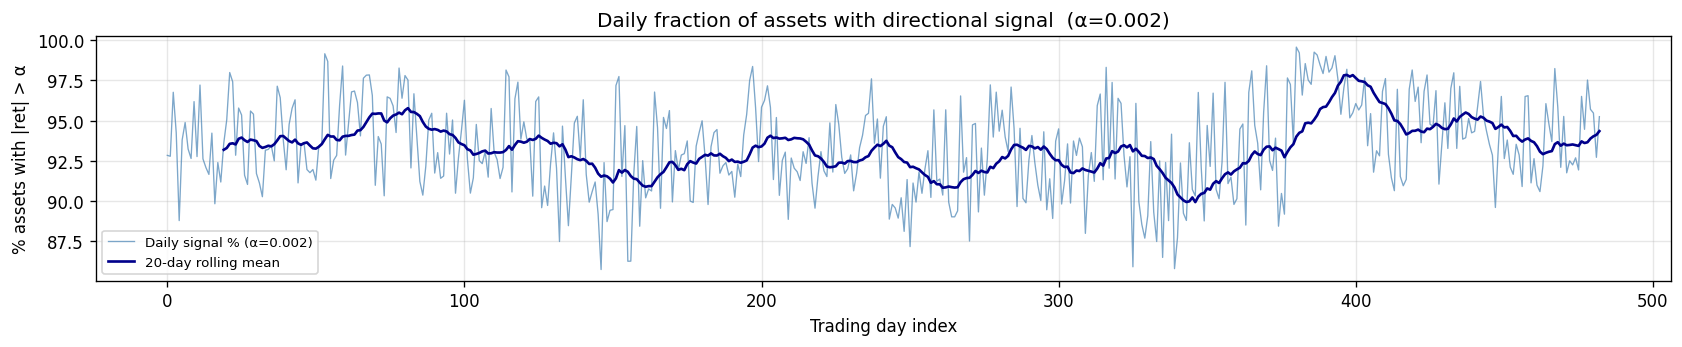

In [31]:
# rolling fraction of directional days (|ret| > CURRENT_ALPHA) across all assets
daily_signal_pct = (
    rets.assign(signal=rets["ret"].abs() > CURRENT_ALPHA).groupby("date")["signal"].mean() * 100
)
# date column is categorical (D001, D002, ...), not datetime — use numeric x-axis
daily_signal_pct = daily_signal_pct.reset_index()
daily_signal_pct["x"] = range(len(daily_signal_pct))

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(
    daily_signal_pct["x"],
    daily_signal_pct["signal"],
    color="steelblue",
    lw=0.8,
    alpha=0.7,
    label=f"Daily signal % (α={CURRENT_ALPHA})",
)
ax.plot(
    daily_signal_pct["x"],
    daily_signal_pct["signal"].rolling(20).mean(),
    color="darkblue",
    lw=1.6,
    label="20-day rolling mean",
)
ax.set_ylabel("% assets with |ret| > α")
ax.set_xlabel("Trading day index")
ax.set_title(f"Daily fraction of assets with directional signal  (α={CURRENT_ALPHA})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 7. Recommendation

Score each candidate α by two criteria:
- **Symmetry**: down% ≈ up% → low imbalance
- **Signal density**: flat% should be ~50–65% so directional classes have enough samples without being too noisy

A composite score ranks candidates; the top pick is printed along with its class breakdown.

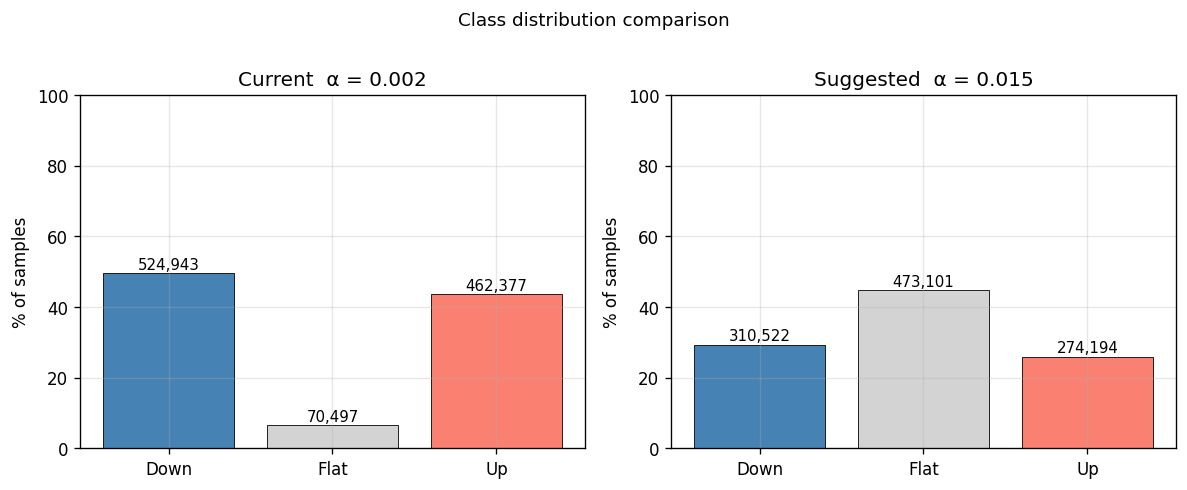

In [33]:
# Side-by-side bar charts: current alpha vs recommended alpha
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, a, title in zip(
    axes,
    [CURRENT_ALPHA, best_alpha],
    [f"Current  α = {CURRENT_ALPHA}", f"Suggested  α = {best_alpha}"],
):
    row = scan.loc[a]
    bars = ax.bar(
        ["Down", "Flat", "Up"],
        [row["pct_down"], row["pct_flat"], row["pct_up"]],
        color=["steelblue", "lightgray", "salmon"],
        edgecolor="black",
        lw=0.5,
    )
    for bar, n in zip(bars, [row["n_down"], row["n_flat"], row["n_up"]]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.set_ylabel("% of samples")
    ax.set_ylim(0, 100)
    ax.set_title(title)

plt.suptitle("Class distribution comparison", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

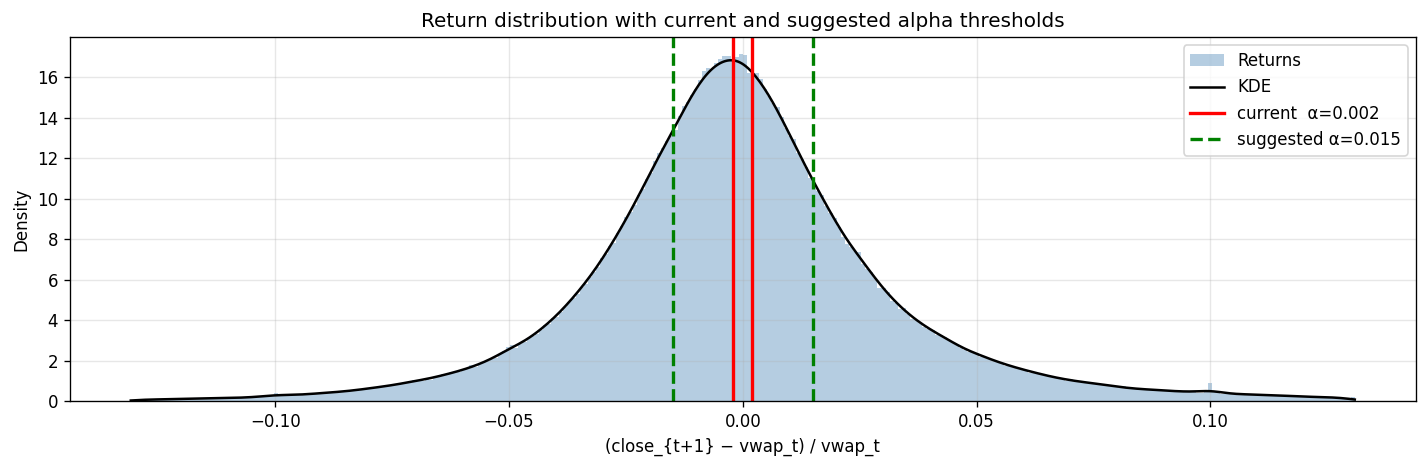

In [34]:
# Final summary plot: histogram with both alphas marked
clip_val = np.percentile(np.abs(r), 99)
r_disp = r[np.abs(r) <= clip_val]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(r_disp, bins=300, density=True, color="steelblue", alpha=0.4, label="Returns")
kde = stats.gaussian_kde(r_disp, bw_method=0.08)
kde_x = np.linspace(r_disp.min(), r_disp.max(), 600)
ax.plot(kde_x, kde(kde_x), "k-", lw=1.5, label="KDE")

ax.axvline(CURRENT_ALPHA, color="red", lw=2.0, linestyle="-", label=f"current  α={CURRENT_ALPHA}")
ax.axvline(-CURRENT_ALPHA, color="red", lw=2.0, linestyle="-")
ax.axvline(best_alpha, color="green", lw=2.0, linestyle="--", label=f"suggested α={best_alpha}")
ax.axvline(-best_alpha, color="green", lw=2.0, linestyle="--")

ax.set_xlabel("(close_{t+1} − vwap_t) / vwap_t")
ax.set_ylabel("Density")
ax.set_title("Return distribution with current and suggested alpha thresholds")
ax.legend()
plt.tight_layout()
plt.show()